# 🛒 VisionGuard — Retail Loss Prevention Demo
**BU.330.740 Large Scale Computing on the Cloud**

This notebook simulates the VisionGuard pipeline:
1. Send a test image to your trained AWS Rekognition Custom Labels model
2. Compare the detected item against a simulated POS transaction log
3. Trigger an alert if a mismatch is found (simulated theft)

---
⚠️ **Before running:** Make sure your Rekognition model is **started** in the AWS Console.

## Step 1 — Install & Configure AWS

In [1]:
# Install required libraries
!pip install boto3 pillow matplotlib -q
print('✅ Libraries ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.6 MB/s eta 0:00:00
✅ Libraries ready


In [ ]:
import boto3
import json
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ─────────────────────────────────────────────────────────────
# FILL THESE IN — from AWS Academy session
# ─────────────────────────────────────────────────────────────
# AWS_ACCESS_KEY_ID     = [insert]
# AWS_SECRET_ACCESS_KEY = [insert]
# AWS_REGION            = [insert]

# model ARN — from the Rekognition Custom Labels model page
#MODEL_ARN = [insert]

MIN_CONFIDENCE = 50   # Minimum confidence % to accept a label

# ─────────────────────────────────────────────────────────────
# Create the Rekognition client
# ─────────────────────────────────────────────────────────────
rekognition = boto3.client(
    'rekognition',
    region_name=AWS_REGION,
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    aws_session_token=AWS_SESSION_TOKEN
)

print('✅ AWS client configured')

✅ AWS client configured


## Step 2 — Where to find your AWS credentials

In AWS Academy:
1. Go to your Learner Lab
2. Click **"AWS Details"** (top right)
3. Click **"Show"** next to CLI credentials
4. Copy `aws_access_key_id`, `aws_secret_access_key`, and `aws_session_token` into the cell above

> ⚠️ These credentials expire when your lab session ends. Re-paste them if you restart the lab.

## Step 3 — Core Detection Function

In [3]:
def detect_item(image_path: str) -> dict:
    """
    Send an image to Rekognition Custom Labels.
    Returns the top detected label and its confidence.
    """
    with open(image_path, 'rb') as f:
        image_bytes = f.read()

    response = rekognition.detect_custom_labels(
        ProjectVersionArn=MODEL_ARN,
        Image={'Bytes': image_bytes},
        MinConfidence=MIN_CONFIDENCE
    )

    labels = response.get('CustomLabels', [])

    if not labels:
        return {'label': 'unknown', 'confidence': 0.0}

    # Return the highest-confidence label
    top = sorted(labels, key=lambda x: x['Confidence'], reverse=True)[0]
    return {
        'label': top['Name'].lower(),
        'confidence': round(top['Confidence'], 2),
        'all_labels': [{'label': l['Name'], 'confidence': round(l['Confidence'], 2)} for l in labels]
    }


def check_mismatch(image_path: str, pos_item: str, pos_price: float, transaction_id: str = 'TXN-001'):
    """
    Core VisionGuard logic:
    Compare what the camera sees vs what the POS log recorded.
    Triggers an alert if they don't match.
    """
    print(f'\n{"="*55}')
    print(f'  Transaction: {transaction_id}')
    print(f'  POS Log:     "{pos_item}"  @ ${pos_price:.2f}')
    print(f'  Image:       {image_path}')
    print(f'{"="*55}')

    # Call Rekognition
    result = detect_item(image_path)
    detected = result['label']
    confidence = result['confidence']

    print(f'  🔍 Camera detected: "{detected}" ({confidence}% confidence)')

    # Show the image
    img = Image.open(image_path)
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')

    # Mismatch check
    if detected != pos_item.lower():
        verdict = 'MISMATCH — ALERT TRIGGERED'
        color = 'red'
        emoji = '🚨'
        print(f'\n  {emoji} {verdict}')
        print(f'     Camera sees "{detected}" but POS shows "{pos_item}"')
        print(f'     ➡ Employee tablet notified. Kiosk paused.')
    else:
        verdict = 'MATCH — OK'
        color = 'green'
        emoji = '✅'
        print(f'\n  {emoji} {verdict}')
        print(f'     Item matches POS log. Transaction cleared.')

    plt.title(f'{emoji} Detected: "{detected}" ({confidence}%)\nPOS: "{pos_item}" — {verdict}',
              color=color, fontsize=9, pad=8)
    plt.tight_layout()
    plt.show()

    return {
        'transaction_id': transaction_id,
        'pos_item': pos_item,
        'detected_item': detected,
        'confidence': confidence,
        'status': 'ALERT' if detected != pos_item.lower() else 'OK'
    }

print('✅ Functions defined')

✅ Functions defined


## Step 4 — Upload Test Images

Upload a few test images using the **Files panel** on the left sidebar in Colab (click the folder icon).

You can use images from your training dataset or download new ones.
Just note the filename and update the test cases below.

## Step 5 — Run Test Cases

### Test Case 1: ✅ Legitimate scan (Apple scanned as Apple)


  Transaction: TXN-001
  POS Log:     "apple"  @ $0.99
  Image:       apple.jpg
  🔍 Camera detected: "unknown" (0.0% confidence)

  🚨 MISMATCH — ALERT TRIGGERED
     Camera sees "unknown" but POS shows "apple"
     ➡ Employee tablet notified. Kiosk paused.


/tmp/ipykernel_31252/4168552828.py:71: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


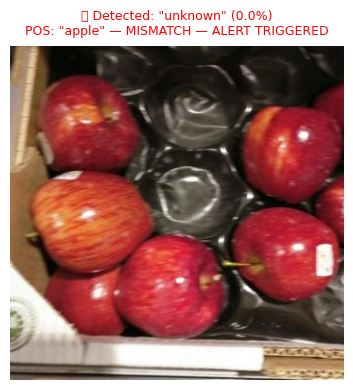

In [12]:
# LEGITIMATE TRANSACTION — should pass
result1 = check_mismatch(
    image_path='apple.jpg',      # ← change to your uploaded image filename
    pos_item='apple',
    pos_price=0.99,
    transaction_id='TXN-001'
)

### Test Case 2: 🚨 Barcode Swap (Banana scanned, but customer holding Apple)


  Transaction: TXN-002
  POS Log:     "banana"  @ $0.29
  Image:       apple.jpg
  🔍 Camera detected: "unknown" (0.0% confidence)

  🚨 MISMATCH — ALERT TRIGGERED
     Camera sees "unknown" but POS shows "banana"
     ➡ Employee tablet notified. Kiosk paused.


/tmp/ipykernel_31252/4168552828.py:71: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


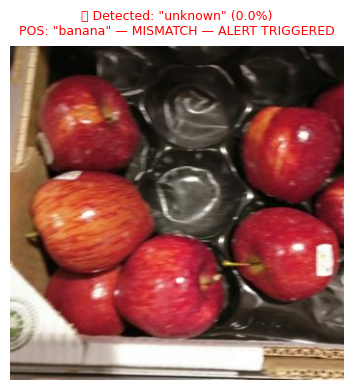

In [13]:
# BARCODE SWAP — expensive item scanned as cheap item
result2 = check_mismatch(
    image_path='apple.jpg',      # ← camera sees an apple
    pos_item='banana',           # ← but POS says banana was scanned (cheaper)
    pos_price=0.29,
    transaction_id='TXN-002'
)

### Test Case 3: 🚨 Sweethearting (Juice scanned, item never passed scanner)


  Transaction: TXN-003
  POS Log:     "banana"  @ $0.29
  Image:       juice.jpg
  🔍 Camera detected: "juice" (99.85% confidence)

  🚨 MISMATCH — ALERT TRIGGERED
     Camera sees "juice" but POS shows "banana"
     ➡ Employee tablet notified. Kiosk paused.


/tmp/ipykernel_31252/4168552828.py:71: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


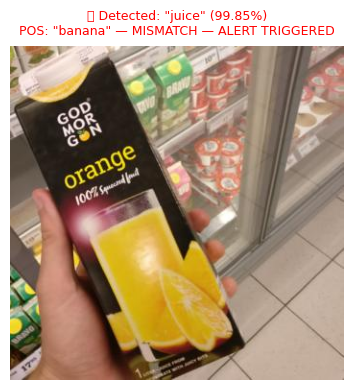

In [14]:
# SWEETHEARTING — expensive item in hand, cheap item on POS
result3 = check_mismatch(
    image_path='juice.jpg',      # ← camera sees juice (~$4.99)
    pos_item='banana',           # ← POS shows banana ($0.29)
    pos_price=0.29,
    transaction_id='TXN-003'
)

### Test Case 4: ✅ Another legitimate scan


  Transaction: TXN-004
  POS Log:     "banana"  @ $0.29
  Image:       banana.jpg
  🔍 Camera detected: "banana" (95.53% confidence)

  ✅ MATCH — OK
     Item matches POS log. Transaction cleared.


/tmp/ipykernel_31252/4168552828.py:71: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


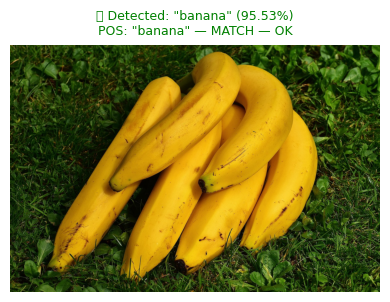

In [15]:
result4 = check_mismatch(
    image_path='banana.jpg',     # ← change to your uploaded image filename
    pos_item='banana',
    pos_price=0.29,
    transaction_id='TXN-004'
)


  Transaction: TXN-005
  POS Log:     "apple"  @ $0.99
  Image:       melon.jpg
  🔍 Camera detected: "melon" (74.26% confidence)

  🚨 MISMATCH — ALERT TRIGGERED
     Camera sees "melon" but POS shows "apple"
     ➡ Employee tablet notified. Kiosk paused.


/tmp/ipykernel_31252/4168552828.py:71: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


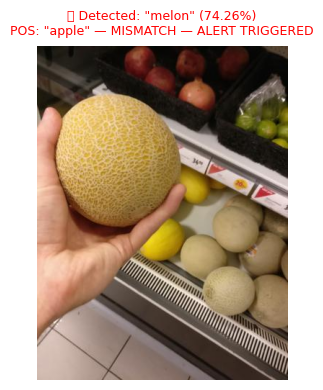

In [16]:
result5 = check_mismatch(
    image_path='melon.jpg',
    pos_item='apple',
    pos_price=0.99,
    transaction_id='TXN-005'
)


  Transaction: TXN-006
  POS Log:     "lemon"  @ $0.89
  Image:       lemon.jpg
  🔍 Camera detected: "unknown" (0.0% confidence)

  🚨 MISMATCH — ALERT TRIGGERED
     Camera sees "unknown" but POS shows "lemon"
     ➡ Employee tablet notified. Kiosk paused.


/tmp/ipykernel_31252/4168552828.py:71: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


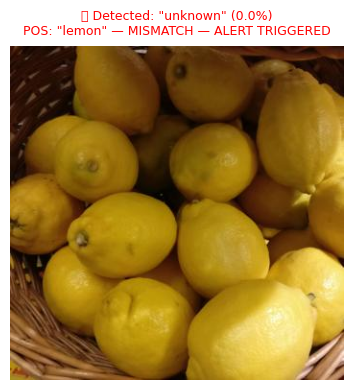

In [18]:
result6 = check_mismatch(
    image_path='lemon.jpg',
    pos_item='lemon',
    pos_price=0.89,
    transaction_id='TXN-006'
)


  Transaction: TXN-007
  POS Log:     "lemon"  @ $0.89
  Image:       lime.jpg
  🔍 Camera detected: "lime" (62.6% confidence)

  🚨 MISMATCH — ALERT TRIGGERED
     Camera sees "lime" but POS shows "lemon"
     ➡ Employee tablet notified. Kiosk paused.


/tmp/ipykernel_31252/4168552828.py:71: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


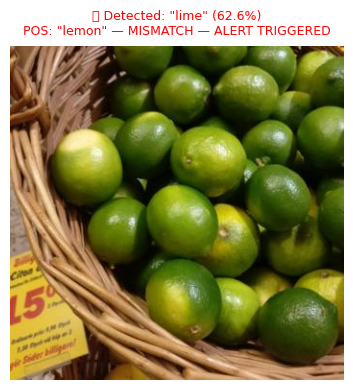

In [19]:
# Tests if model can distinguish between visually similar items
result7 = check_mismatch(
    image_path='lime.jpg',        # lime and lemon look very similar
    pos_item='lemon',
    pos_price=0.89,
    transaction_id='TXN-007'
)


  Transaction: TXN-008
  POS Log:     "banana"  @ $0.29
  Image:       juice.jpg
  🔍 Camera detected: "juice" (99.85% confidence)

  🚨 MISMATCH — ALERT TRIGGERED
     Camera sees "juice" but POS shows "banana"
     ➡ Employee tablet notified. Kiosk paused.


/tmp/ipykernel_31252/4168552828.py:71: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


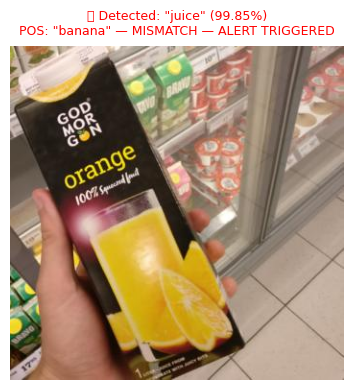

In [20]:
# Most financially damaging scenario — premium item passed off as cheapest item
result8 = check_mismatch(
    image_path='juice.jpg',       # juice ~$4.99
    pos_item='banana',            # banana ~$0.29 — maximum price gap
    pos_price=0.29,
    transaction_id='TXN-008'
)


  Transaction: TXN-009
  POS Log:     "apple"  @ $0.99
  Image:       partial_apple.jpg
  🔍 Camera detected: "apple" (53.93% confidence)

  ✅ MATCH — OK
     Item matches POS log. Transaction cleared.


/tmp/ipykernel_31252/4168552828.py:71: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


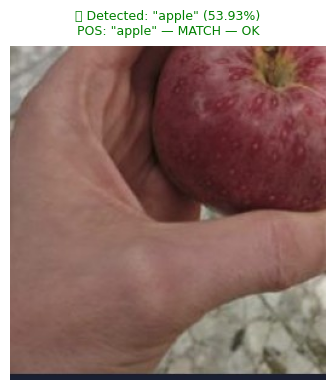

In [22]:
# Lower MIN_CONFIDENCE temporarily to test borderline detections
result9 = check_mismatch(
    image_path='partial_apple.jpg',   # upload a cropped or partially obscured apple
    pos_item='apple',
    pos_price=0.99,
    transaction_id='TXN-009'
)


  Transaction: TXN-010
  POS Log:     "tomato"  @ $0.79
  Image:       pepper.jpg
  🔍 Camera detected: "pepper" (95.83% confidence)

  🚨 MISMATCH — ALERT TRIGGERED
     Camera sees "pepper" but POS shows "tomato"
     ➡ Employee tablet notified. Kiosk paused.


/tmp/ipykernel_31252/4168552828.py:71: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


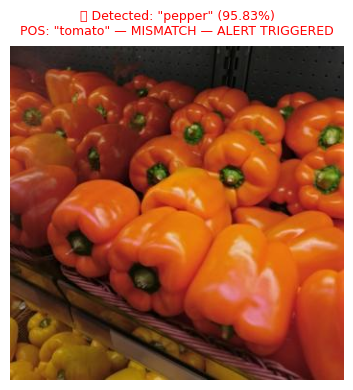

In [23]:
# Tests detection across vegetable category — similar colors, different shapes
result10 = check_mismatch(
    image_path='pepper.jpg',
    pos_item='tomato',
    pos_price=0.79,
    transaction_id='TXN-010'
)

## Step 6 — Results Summary (for Slide 11)

In [24]:
results = [result1, result2, result3, result4, result5, result6, result7, result8, result9, result10]

print('\n' + '='*65)
print('  VISIONGUARD — FULL PIPELINE RESULTS SUMMARY')
print('='*65)
print(f'{"TXN ID":<12} {"POS Item":<15} {"Detected":<15} {"Conf%":<8} {"Status"}')
print('-'*65)

alerts = 0
for r in results:
    status_icon = '🚨 ALERT' if r['status'] == 'ALERT' else '✅ OK'
    print(f"{r['transaction_id']:<12} {r['pos_item']:<15} {r['detected_item']:<15} {str(r['confidence'])+'%':<8} {status_icon}")
    if r['status'] == 'ALERT':
        alerts += 1

print('-'*65)
print(f'  Total transactions : {len(results)}')
print(f'  Alerts triggered   : {alerts}  ({alerts/len(results)*100:.0f}%)')
print(f'  Clear transactions : {len(results) - alerts}')
print(f'  Theft prevented    : {alerts} incident(s) flagged before payment')
print('='*65)


  VISIONGUARD — FULL PIPELINE RESULTS SUMMARY
TXN ID       POS Item        Detected        Conf%    Status
-----------------------------------------------------------------
TXN-001      apple           unknown         0.0%     🚨 ALERT
TXN-002      banana          unknown         0.0%     🚨 ALERT
TXN-003      banana          juice           99.85%   🚨 ALERT
TXN-004      banana          banana          95.53%   ✅ OK
TXN-005      apple           melon           74.26%   🚨 ALERT
TXN-006      lemon           unknown         0.0%     🚨 ALERT
TXN-007      lemon           lime            62.6%    🚨 ALERT
TXN-008      banana          juice           99.85%   🚨 ALERT
TXN-009      apple           apple           53.93%   ✅ OK
TXN-010      tomato          pepper          95.83%   🚨 ALERT
-----------------------------------------------------------------
  Total transactions : 10
  Alerts triggered   : 8  (80%)
  Clear transactions : 2
  Theft prevented    : 8 incident(s) flagged before payment


## ⚠️ Step 7 — STOP YOUR MODEL

**Do this immediately after you finish testing to avoid charges.**

Go to AWS Console → Rekognition → Custom Labels → Projects → Your Model → **Stop model**

Or run the cell below:

In [ ]:
# Uncomment and run this when you are done testing

# response = rekognition.stop_project_version(ProjectVersionArn=MODEL_ARN)
# print(f'Model status: {response["Status"]}')
# print('✅ Model stopped — no further charges')